
# Module 25: DBSCAN & Hierarchical Clustering

This notebook is designed for hands-on practice.



## Dataset 1: Blob Dataset with Different Densities

This dataset contains clusters with different densities.
DBSCAN should behave differently for each cluster.


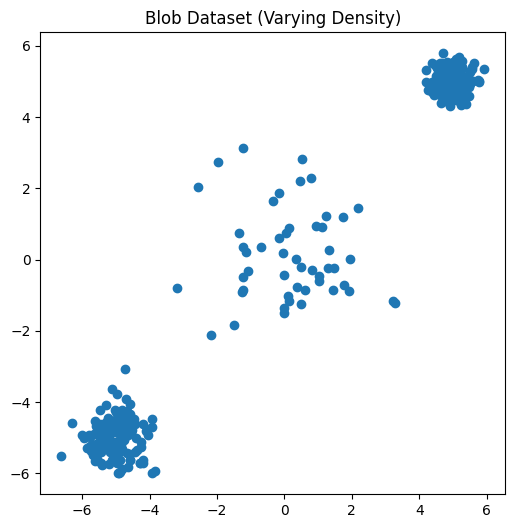

In [16]:
#Done for you
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X_blobs, _ = make_blobs(
    n_samples=[150, 50, 200],
    centers=[(-5, -5), (0, 0), (5, 5)],
    cluster_std=[0.5, 1.5, 0.3],
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_blobs[:,0], X_blobs[:,1])
plt.title("Blob Dataset (Varying Density)")
plt.show()


### TODO 1: Scaling

Scale the dataset using StandardScaler.

Think:
- Why is scaling important here?
- What happens if we skip scaling?


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import pandas as pd

# TODO: Scale the dataset and verify that the mean is ~0 and variance is ~1
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_blobs)

df_scaled = pd.DataFrame(X_scaled, columns=["Feature 1", "Feature 2"])
print(df_scaled.mean())
print(df_scaled.var())
# Challenge: Check the summary statistics of the scaled data
print("\nSummary Statistics:")
print(df_scaled.describe())


Feature 1    7.605028e-17
Feature 2   -6.772360e-17
dtype: float64
Feature 1    1.002506
Feature 2    1.002506
dtype: float64

Summary Statistics:
          Feature 1     Feature 2
count  4.000000e+02  4.000000e+02
mean   5.773160e-17 -6.439294e-17
std    1.001252e+00  1.001252e+00
min   -1.552926e+00 -1.423594e+00
25%   -1.172044e+00 -1.159617e+00
50%    6.645817e-01  6.608559e-01
75%    9.330801e-01  9.311268e-01
max    1.132521e+00  1.103948e+00



### TODO 2: DBSCAN on Blob Dataset

Apply DBSCAN.
Experiment with different values of eps and min_samples.


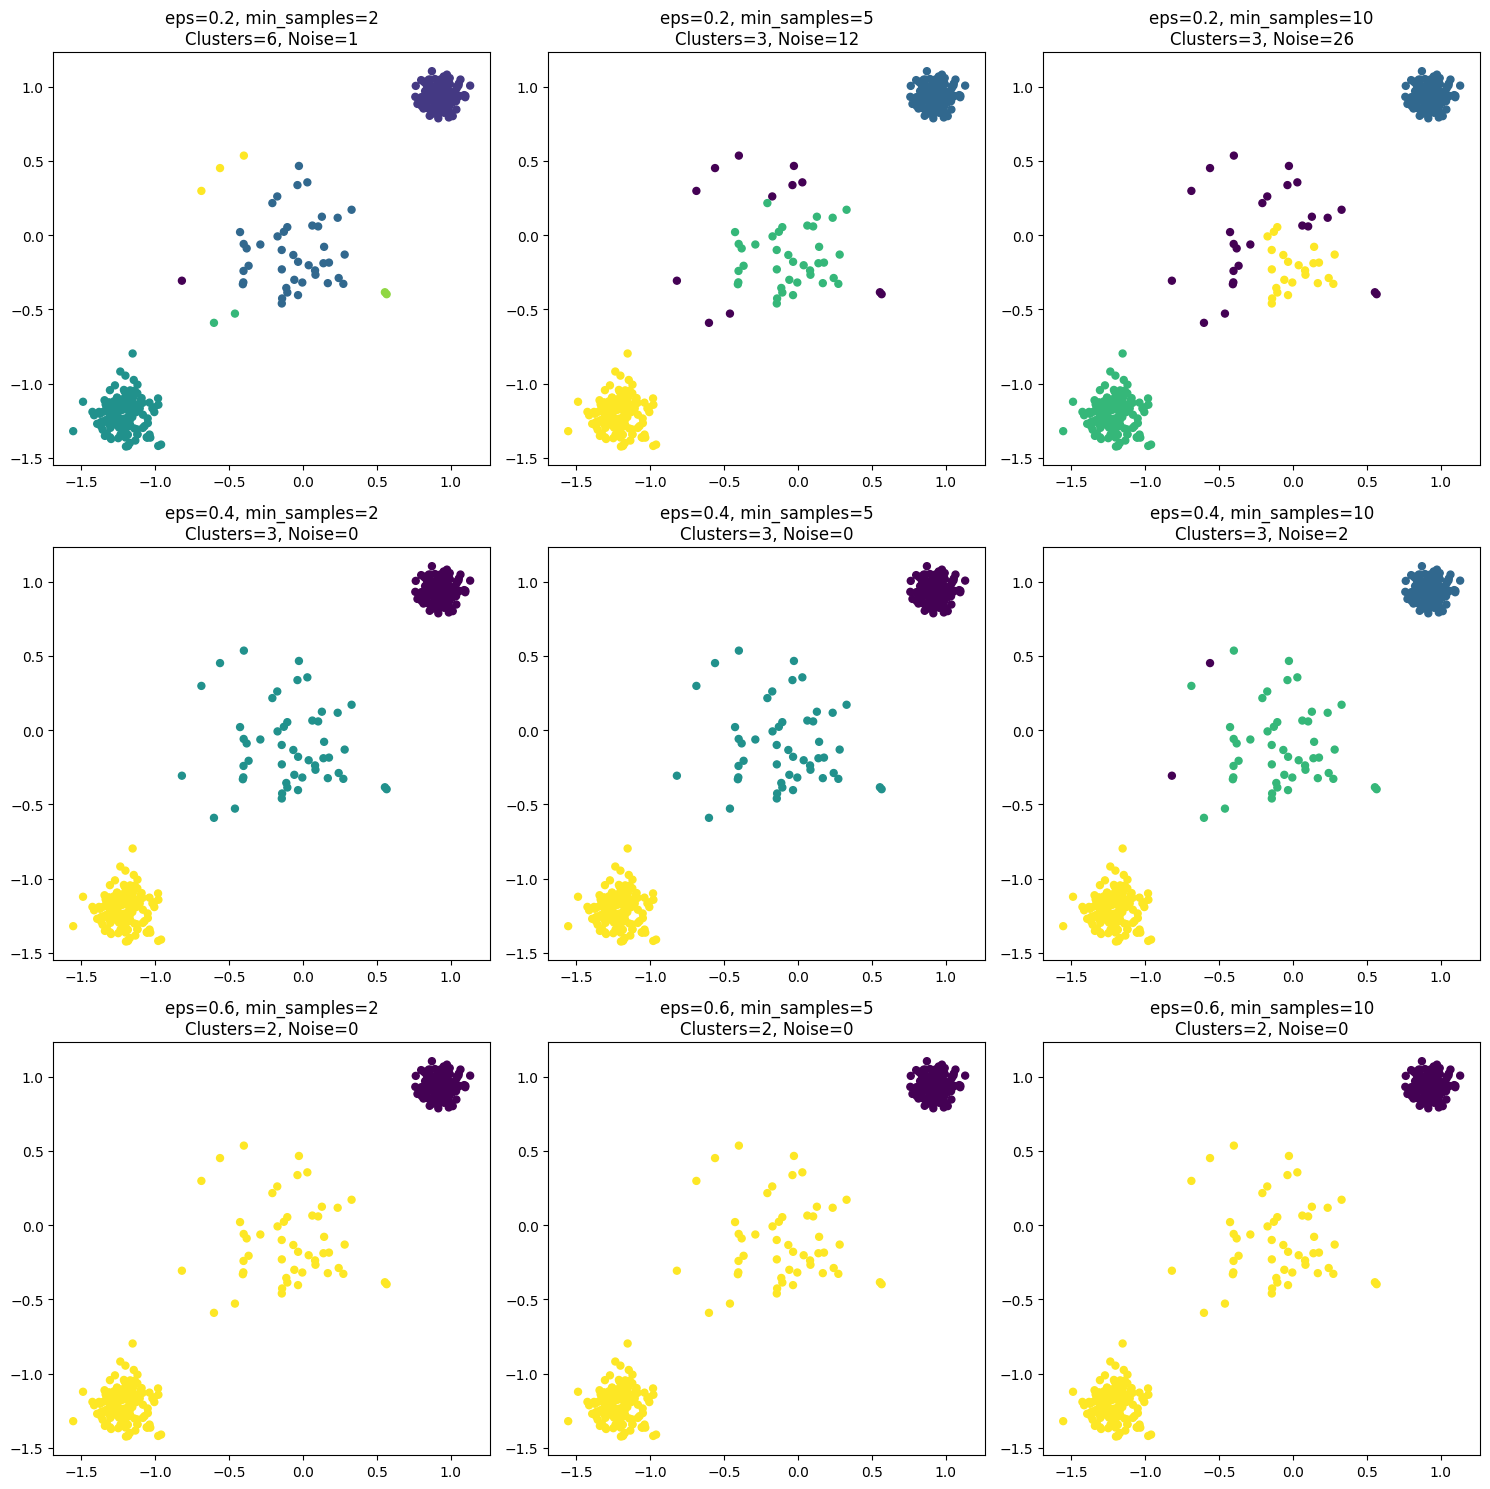

In [27]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# TODO: Implement DBSCAN
# Challenge: Create a function that loops through a grid of eps [0.2, 0.4, 0.6]
# and min_samples [2, 5, 10] and plots the results in a 3x3 subplot grid.

def plot_dbscan(X_scaled):
  eps_vals=[0.2,0.4,0.6]
  min_sample_vals=[2,5,10]
  fig, axes = plt.subplots(3, 3, figsize=(15, 15))

  for i,eps in enumerate(eps_vals):
    for j,msam in enumerate(min_sample_vals):
      # training
      dbscan=DBSCAN(eps=eps,min_samples=msam)
      labels=dbscan.fit_predict(X_scaled)

      n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
      n_noise = np.sum(labels == -1)

      ax=axes[i,j]
      scatter = ax.scatter(
                X_scaled[:, 0],
                X_scaled[:, 1],
                c=labels,
                cmap="viridis",
                s=25
            )
      ax.set_title(
                f"eps={eps}, min_samples={msam}\n"
                f"Clusters={n_clusters}, Noise={n_noise}"
            )

  plt.tight_layout()
  plt.show()


# Run the function
plot_dbscan(X_scaled)




### TODO 3: k-Distance Plot

Use a k-distance plot to estimate eps.


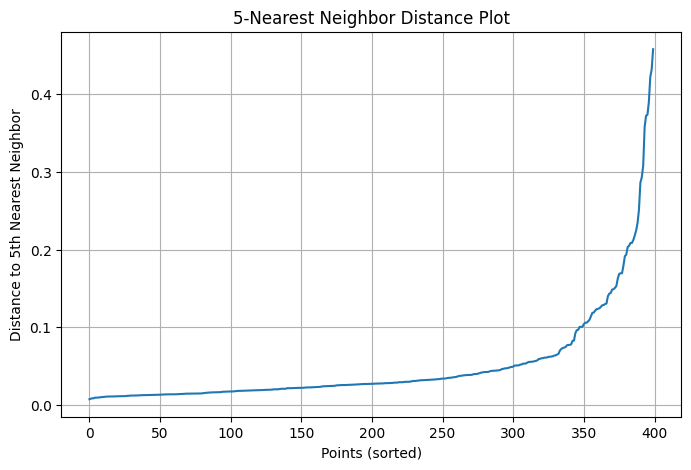

In [32]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# TODO: Create k-distance plot
# Challenge: Use the 'knee' point detection logic.
# Calculate distances to the 5th nearest neighbor, sort them, and plot.

# Find the distance to the 5th nearest neighbor
neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

# Distance to the 5th nearest neighbor
k_distances = distances[:, 4]

# Sort the distances
k_distances = np.sort(k_distances)

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title("5-Nearest Neighbor Distance Plot")
plt.xlabel("Points (sorted)")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.grid(True)
plt.show()




## Dataset 2: Circular Dataset

This dataset contains non-linear circular clusters.


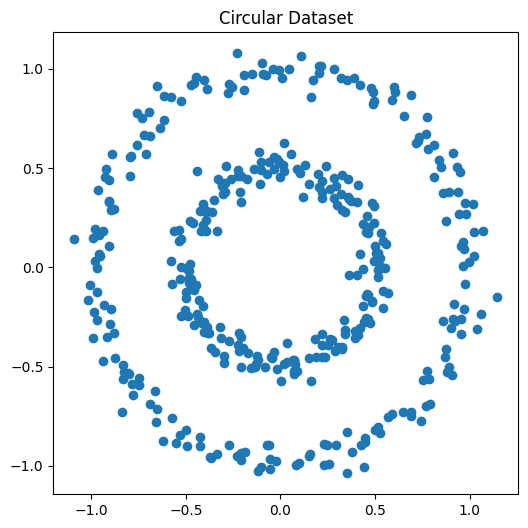

In [34]:
#Done for you
from sklearn.datasets import make_circles

X_circles, _ = make_circles(
    n_samples=400,
    factor=0.5,
    noise=0.05,
    random_state=42
)

plt.figure(figsize=(6,6))
plt.scatter(X_circles[:,0], X_circles[:,1])
plt.title("Circular Dataset")
plt.show()


### TODO 4: DBSCAN on Circular Data

Apply DBSCAN and observe cluster shape.


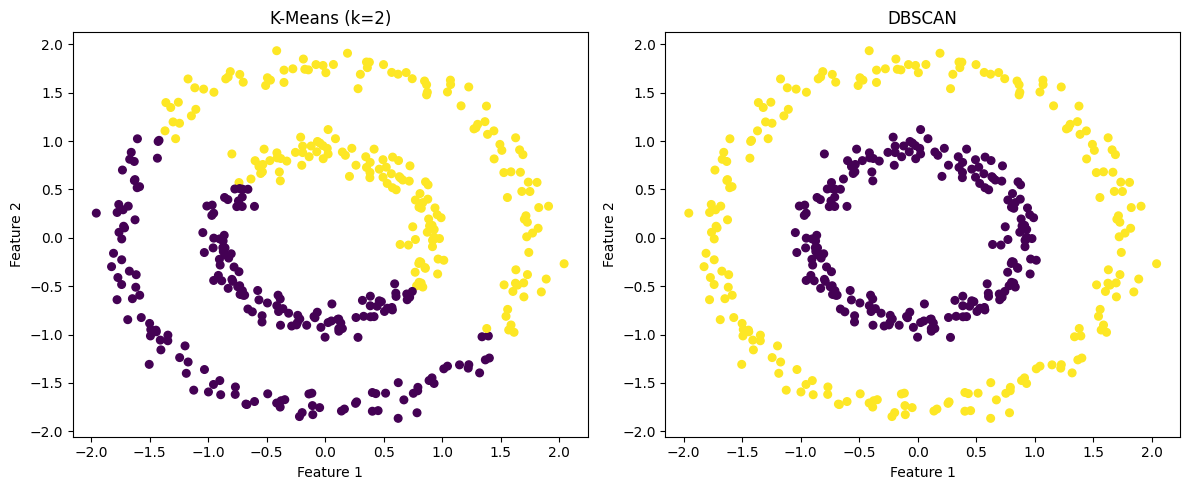

In [37]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Ensure data is generated

# TODO: Compare DBSCAN results side-by-side with K-Means (k=2)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_circles)

# K-Means (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Plot comparison
plt.figure(figsize=(12,5))

# K-Means
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=kmeans_labels, cmap='viridis', s=30)
plt.title("K-Means (k=2)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# DBSCAN
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=dbscan_labels, cmap='viridis', s=30)
plt.title("DBSCAN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# KMeans (Expect failure for non-convex shapes)

# DBSCAN (Expect success for dense regions)



## Hierarchical Clustering Practice



### TODO 5: Agglomerative Clustering

Try different linkage methods:
single, complete, average, ward


In [38]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

# TODO: Apply hierarchical clustering
# Challenge: For each linkage method, calculate the Silhouette Score.

# Different linkage methods
linkages = ["ward", "complete", "average", "single"]

for linkage in linkages:

    # Ward linkage only works with Euclidean distance
    model = AgglomerativeClustering(
        n_clusters=2,
        linkage=linkage
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"Linkage: {linkage}")
    print(f"Silhouette Score: {score:.4f}\n")


Linkage: ward
Silhouette Score: 0.3326

Linkage: complete
Silhouette Score: 0.3470

Linkage: average
Silhouette Score: 0.3483

Linkage: single
Silhouette Score: 0.1108




### TODO 6: Dendrogram

Create a dendrogram using Ward linkage.


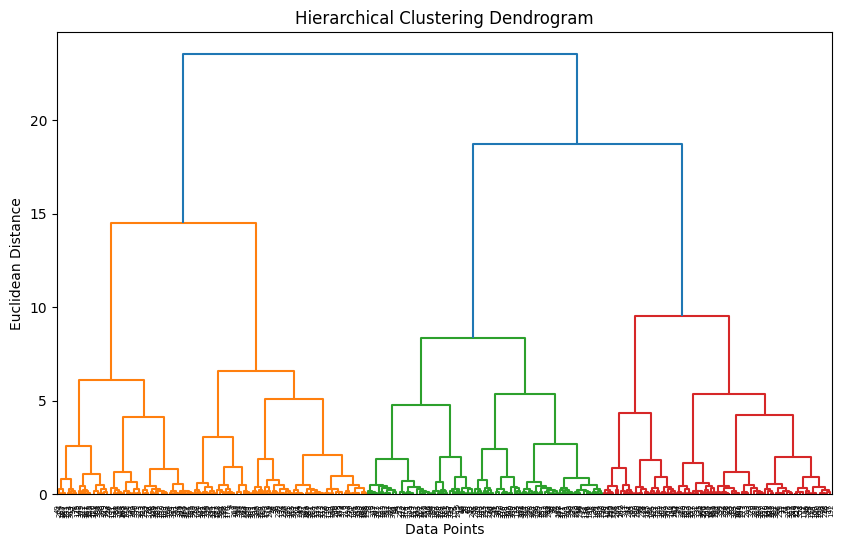

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage

# TODO: Create dendrogram here

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute the linkage matrix
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

## The Grand Challenge: 3D Density Optimization

In this final, hard challenge, we will step into 3D space and automate our parameter selection.

### Requirements:
1. **Generate 3D Data**: Use `make_blobs` to create 1000 samples in 3D space with varying standard deviations.
2. **Parameter Grid Search**: Write a loop that tests `eps` from 0.1 to 1.0 and `min_samples` from 2 to 10.
3. **Optimization**: Find the combination that maximizes the `silhouette_score` (excluding noise points).
4. **3D Visualization**: Plot the final optimized clusters using a 3D scatter plot.